In [1]:
from HPNet_Pipeline import HPNet_Pipeline
import torch 
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import gc
from tqdm.notebook import tqdm



LEBEDEV = 'lebedev'
POINTS_162 = '162_points'

if torch.cuda.is_available():
    DEVICE = torch.device("cuda:0")
    print("Device Name:", torch.cuda.get_device_name(DEVICE))
else:
    DEVICE = torch.device("cpu")
    print("Device Name: CPU")
torch.cuda.empty_cache()  # Free up unused memory on GPU
gc.collect()  # Clean up unused memory on CPU


Device Name: NVIDIA GeForce RTX 4080 SUPER


36

In [2]:
dataset_path = r"data\ModelDataSets\WSJ_4_3_25"
grid = POINTS_162
pipeline = HPNet_Pipeline(dataset_path=dataset_path, grid_type=grid)

In [3]:
pipeline.init_params(
    batch_size=1,
    n_fft=256,
    T=10,
    init_mu=1e-3,
    init_ro=1e-3,
    num_iters=10000,
    version=5,
    device=DEVICE,
)

Optimization Method : GD_lagrange_multi 


In [4]:
audio_id,low_order_anmt,high_order_anmt = pipeline.train_set[0]
print(audio_id,low_order_anmt.shape)


22 torch.Size([250, 4, 129])


DU_Optimizer:   0%|          | 0/10000 [00:00<?, ?it/s]

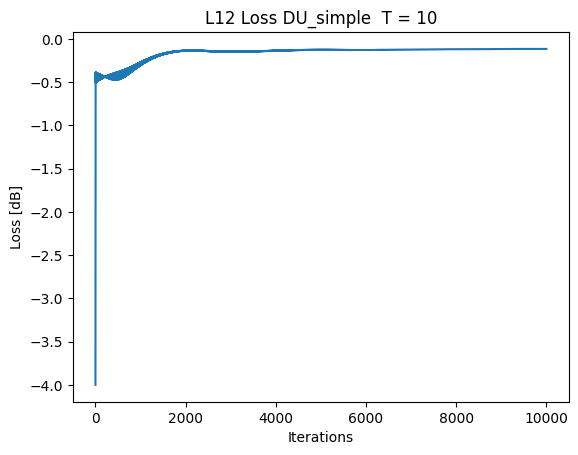

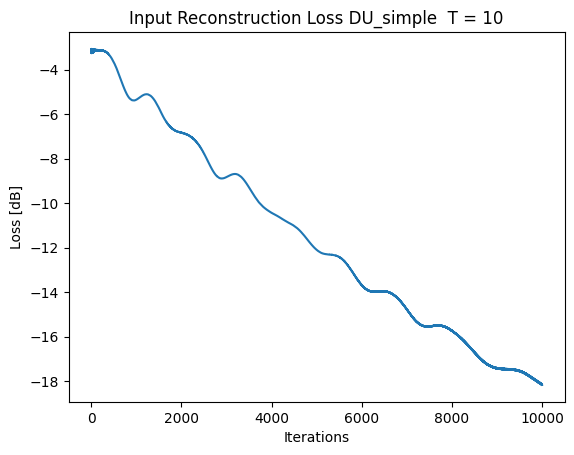

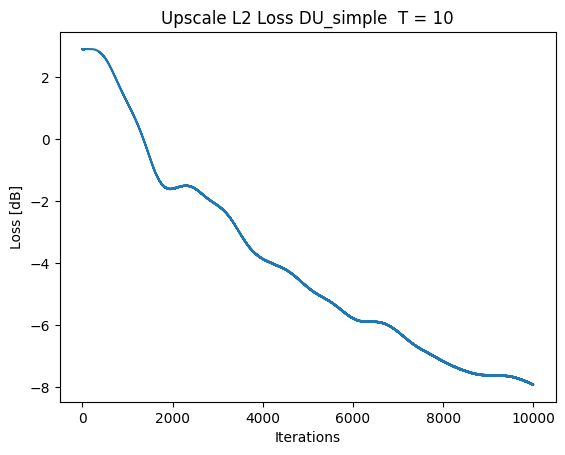

Upscaled Loss : tensor([-7.9036], device='cuda:0')


In [ ]:
with torch.no_grad():
    #Runs with init mu/ro only
    pipeline.run_optimizer(
        from_iter=0,
        to_iter=10000,
        low_order_stft=low_order_anmt.unsqueeze(0),
        high_order_stft=high_order_anmt.unsqueeze(0),
        progress_per_iter=True,
        classic_model=True
    )
    print(f"Upscaled Loss : {pipeline.classic_opt.upscaled_loss(loss_in_dB=True)}")

In [6]:
s_t,lagarange = pipeline.classic_opt.get_current_state()

In [7]:
epochs = 1000
num_iters = 10
loss_per_epoch = list()
for epoch in tqdm(range(epochs)):
    pipeline.run_optimizer(
        from_iter=0,
        to_iter=num_iters,
        low_order_stft=low_order_anmt.unsqueeze(0),
        high_order_stft=high_order_anmt.unsqueeze(0),
        progress_per_iter=False,
        init_lagrange=lagarange.clone(),
        init_st=s_t.clone(),
        disable_tqdm=True,
    )
    loss  = pipeline.du_opt.upscaled_loss()
    pipeline.training_opt.zero_grad()
    loss.backward()
    pipeline.training_opt.step()
    loss_per_epoch.append(10*torch.log10(loss).item())
    print(f"Epoch {epoch} | Loss : {loss_per_epoch[-1]} dB")

plt.plot(loss_per_epoch)
plt.xlabel("Epochs")
plt.ylabel("Loss (dB)")
plt.title("Upscale Loss")

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 0 | Loss : -7.910016775131226 dB
Epoch 1 | Loss : -7.921689748764038 dB
Epoch 2 | Loss : -7.927180528640747 dB
Epoch 3 | Loss : -7.92502760887146 dB
Epoch 4 | Loss : -7.925175428390503 dB
Epoch 5 | Loss : -7.9286128282547 dB
Epoch 6 | Loss : -7.9316794872283936 dB
Epoch 7 | Loss : -7.930065989494324 dB
Epoch 8 | Loss : -7.930530309677124 dB
Epoch 9 | Loss : -7.932702898979187 dB
Epoch 10 | Loss : -7.934665679931641 dB
Epoch 11 | Loss : -7.931551933288574 dB
Epoch 12 | Loss : -7.927998900413513 dB
Epoch 13 | Loss : -7.923539876937866 dB
Epoch 14 | Loss : -7.924738526344299 dB
Epoch 15 | Loss : -7.93118417263031 dB
Epoch 16 | Loss : -7.9361045360565186 dB
Epoch 17 | Loss : -7.9368966817855835 dB
Epoch 18 | Loss : -7.936347723007202 dB
Epoch 19 | Loss : -7.935803532600403 dB
Epoch 20 | Loss : -7.935622334480286 dB
Epoch 21 | Loss : -7.935344576835632 dB
Epoch 22 | Loss : -7.934385538101196 dB
Epoch 23 | Loss : -7.933681607246399 dB
Epoch 24 | Loss : -7.93257474899292 dB
Epoch 25 | L